# 2. Training and evaluating EclipseNETs

An EclipseNET is a small network that maps the Sun direction and a point of the plane orthogonal to it to the value of the eclipse function (Section 3 of the paper). Its six inputs are `[cos(az), sin(az), cos(el), sin(el), x, y]`.

This notebook covers:

1. the four bodies (Table 1);
2. the losses of the networks released with the paper (Table 2);
3. the silhouettes they predict for a Sun direction they were not trained on (Figure 2, panel D);
4. the training of a SIREN and of a feed-forward network for 67P (Figure 3).

It needs the datasets in `datasets/`, which are stored with git lfs (`git lfs pull`).

In [1]:
import sys
sys.path.append('../')  # the repository root, where the eclipsenets package is

import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import eclipsenets as en

NAMES = ["Bennu", "Itokawa", "67P", "Eros"]

## The bodies (Table 1)

In [2]:
print(f"{'':8s} {'N mesh':>7s} {'N mascons':>10s} {'period [hr]':>12s} {'L [km]':>8s} {'mass [kg]':>10s}")
for name in NAMES:
    body = en.load_body(name, low_poly_mascons=False)
    print(f"{name:8s} {len(body.mesh_points):7,d} {len(body.mascon_masses):10,d} {body.rotation_period:12.4f} "
          f"{body.L / 1e3:8.4f} {body.mass:10.3e}")

          N mesh  N mascons  period [hr]   L [km]  mass [kg]
Bennu      7,374     75,150       4.2960   0.5634  7.329e+10
Itokawa    8,112    100,363      12.1320   0.5607  3.510e+10
67P        9,149     57,259      12.4043   5.0026  9.982e+12
Eros       7,374     97,824       5.2700  32.6622  6.687e+15


## The networks of the paper (Table 2)

`models/ffnn_vs_siren` holds, for each body, a SIREN and a feed-forward network (FFNN), both with 2,369 parameters. `load_pretrained` returns them.

In [3]:
for kind in ["siren", "ffnn"]:
    model = en.load_pretrained("67P", kind)
    print(f"{kind}: {en.count_parameters(model):,} parameters")
model

siren: 2,369 parameters
ffnn: 2,369 parameters


FFNN(
  (layers): ModuleList(
    (0): Linear(in_features=6, out_features=32, bias=True)
    (1-2): 2 x Linear(in_features=32, out_features=32, bias=True)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

The training and validation sets are in `datasets/`: `published_dataset_path` gives their files. They hold about 2.3 million and 0.9 million samples per body, about ten times fewer than the 22 million and 9 million reported in the paper. 

In [4]:
def load_datasets(name):
    return en.load_dataset(en.published_dataset_path(name, "train")), en.load_dataset(en.published_dataset_path(name, "valid"))

In [5]:
# Table 2 of the paper: (training loss, validation loss)
PAPER = {
    ("Bennu", "ffnn"): (3.5295e-5, 3.6508e-5), ("Bennu", "siren"): (1.9906e-5, 2.1773e-5),
    ("Itokawa", "ffnn"): (8.0184e-5, 8.4136e-5), ("Itokawa", "siren"): (4.7082e-5, 4.9863e-5),
    ("67P", "ffnn"): (7.9564e-5, 8.1466e-5), ("67P", "siren"): (4.6469e-5, 4.9408e-5),
    ("Eros", "ffnn"): (9.3738e-5, 9.8826e-5), ("Eros", "siren"): (4.2137e-5, 4.5850e-5),
}

print(f"{'':8s} {'':6s} {'training loss':^25s} {'validation loss':^25s}")
print(f"{'':8s} {'':6s} {'here':>12s} {'paper':>12s} {'here':>12s} {'paper':>12s}")
for name in NAMES:
    train, valid = load_datasets(name)
    for kind in ["ffnn", "siren"]:
        model = en.load_pretrained(name, kind)
        print(f"{name:8s} {kind:6s} {en.evaluate_mse(model, train):12.4e} {PAPER[name, kind][0]:12.4e} "
              f"{en.evaluate_mse(model, valid):12.4e} {PAPER[name, kind][1]:12.4e}")

                      training loss            validation loss     
                        here        paper         here        paper


Bennu    ffnn     3.5295e-05   3.5295e-05   3.6508e-05   3.6508e-05


Bennu    siren    1.9906e-05   1.9906e-05   2.1773e-05   2.1773e-05


Itokawa  ffnn     7.7693e-05   8.0184e-05   8.1272e-05   8.4136e-05


Itokawa  siren    4.6057e-05   4.7082e-05   4.8885e-05   4.9863e-05


67P      ffnn     7.9564e-05   7.9564e-05   8.1466e-05   8.1466e-05


67P      siren    4.6469e-05   4.6469e-05   4.9408e-05   4.9408e-05


Eros     ffnn     9.3738e-05   9.3738e-05   9.8826e-05   9.8826e-05


Eros     siren    4.2137e-05   4.2137e-05   4.5850e-05   4.5850e-05


The losses of Bennu, 67P and Eros are the ones of the paper. The ones of Itokawa are close to them, on the datasets that were generated again. For every body the SIREN has a lower loss than the feed-forward network.

## Predicted silhouettes (Figure 2, panel D)

The silhouette predicted by a network is its zero level. Here it is drawn for a Sun direction that is not in the training set, on top of the projected vertices of the shape model.

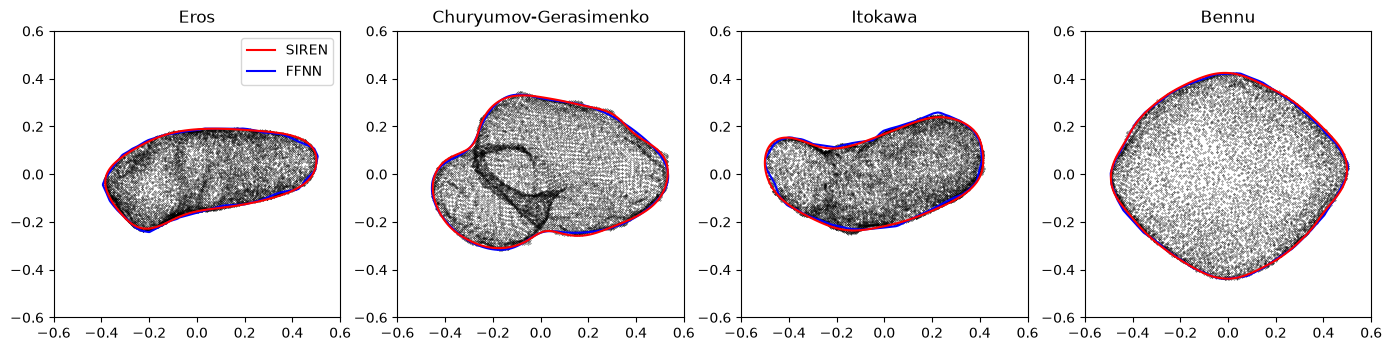

In [6]:
sun_direction = en.sph2cart(az=120., el=75.)

fig, axes = plt.subplots(1, 4, figsize=(17, 4.5))
for ax, name in zip(axes, ["Eros", "67P", "Itokawa", "Bennu"]):
    body = en.load_body(name)
    projected = en.project_to_2d(body.mesh_points, sun_direction)
    ax.plot(projected[:, 0], projected[:, 1], '.', color='black', markersize=0.5)
    en.plot_silhouette(en.load_pretrained(name, "ffnn"), sun_direction, ax=ax, extent=0.6, colors='blue')
    en.plot_silhouette(en.load_pretrained(name, "siren"), sun_direction, ax=ax, extent=0.6, colors='red')
    ax.set_title(body.name)
axes[0].plot([], [], 'r', label='SIREN')
axes[0].plot([], [], 'b', label='FFNN')
axes[0].legend(loc='upper right');

## Training (Figure 3)

`en.train` trains a network on a dataset: Adam, a learning rate of $10^{-3}$ annealed with a cosine schedule, batches of 128 samples and 100 epochs. The same can be done from the command line with `scripts/train.py`.

Three networks with 2,369 parameters are trained for 67P: a SIREN, and feed-forward networks with tanh and with ReLU activations. Each takes about half an hour on a laptop CPU, so the results are kept in `models/runs` and loaded from there when the notebook is run again.

In [7]:
RUNS = Path("../models/runs")
EPOCHS = 100
train_data, valid_data = load_datasets("67P")

def trained(name, epochs=EPOCHS, **architecture):
    """Trains a network for 67P, or loads it if it has been trained already."""
    config = en.TrainingConfig(epochs=epochs, seed=0, checkpoint_dir=str(RUNS / f"chu-ger_{name}"), **architecture)
    history_file = Path(config.checkpoint_dir) / f"{config.model_type}_history.pkl"
    if not history_file.exists():
        en.train(train_data, valid_data, config, progress=False)
    with open(history_file, "rb") as f:
        history = pickle.load(f)
    return en.load_model(Path(config.checkpoint_dir) / f"{config.model_type}_best.pt"), history

ARCHITECTURES = {
    "siren": dict(model_type="siren"),
    "ffnn_tanh": dict(model_type="ffnn", activation="tanh"),
    "ffnn_relu": dict(model_type="ffnn", activation="relu"),
}
models, histories = {}, {}
for name, architecture in ARCHITECTURES.items():
    models[name], histories[name] = trained(name, **architecture)

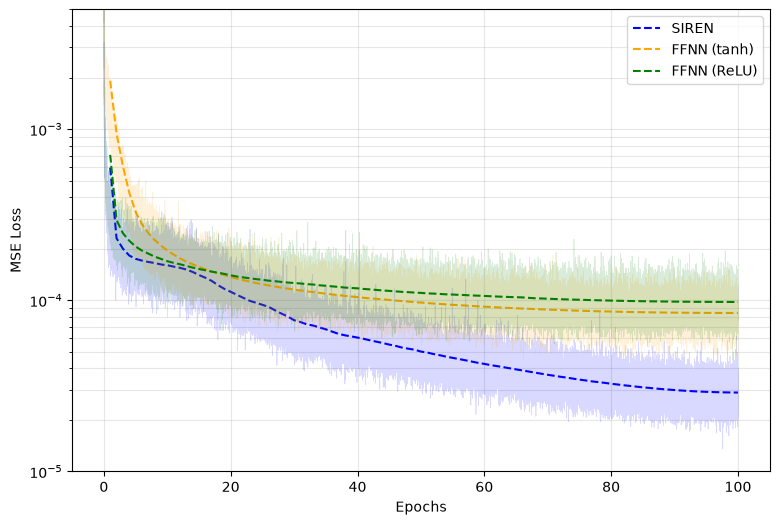

In [8]:
COLORS = {"siren": "blue", "ffnn_tanh": "orange", "ffnn_relu": "green"}
LABELS = {"siren": "SIREN", "ffnn_tanh": "FFNN (tanh)", "ffnn_relu": "FFNN (ReLU)"}

fig, ax = plt.subplots(figsize=(9, 6))
for name, history in histories.items():
    batch_losses = np.array(history["batch_losses"])
    steps = np.arange(len(batch_losses)) / len(batch_losses) * EPOCHS
    ax.plot(steps[::20], batch_losses[::20], color=COLORS[name], alpha=0.15, linewidth=0.5)
    ax.plot(np.arange(1, EPOCHS + 1), history["train_losses"], '--', color=COLORS[name], label=LABELS[name])
ax.set_yscale('log')
ax.set_ylim(1e-5, 5e-3)
ax.set_xlabel('Epochs')
ax.set_ylabel('MSE Loss')
ax.grid(True, which='both', alpha=0.3)
ax.legend();

In [9]:
print(f"{'':12s} {'training loss':>14s} {'validation loss':>16s}")
for name, history in histories.items():
    print(f"{LABELS[name]:12s} {history['train_losses'][-1]:14.4e} {history['valid_losses'][-1]:16.4e}")
print(f"Paper, SIREN {PAPER['67P', 'siren'][0]:14.4e} {PAPER['67P', 'siren'][1]:16.4e}")
print(f"Paper, FFNN  {PAPER['67P', 'ffnn'][0]:14.4e} {PAPER['67P', 'ffnn'][1]:16.4e}")

              training loss  validation loss
SIREN            2.8917e-05       3.0102e-05
FFNN (tanh)      8.4323e-05       8.7007e-05
FFNN (ReLU)      9.7814e-05       1.0280e-04
Paper, SIREN     4.6469e-05       4.9408e-05
Paper, FFNN      7.9564e-05       8.1466e-05


As in the paper, the SIREN reaches a lower loss than the feed-forward networks, and gets there faster. Since the feed-forward network released for 67P uses tanh, the tanh curve is the counterpart of the curve labelled ReLU in Figure 3 of the paper.

The insets of Figure 3 show the silhouettes after the first and after the last epoch, for two Sun directions outside the training set. The networks after one epoch are obtained by training for a single epoch from the same seed.

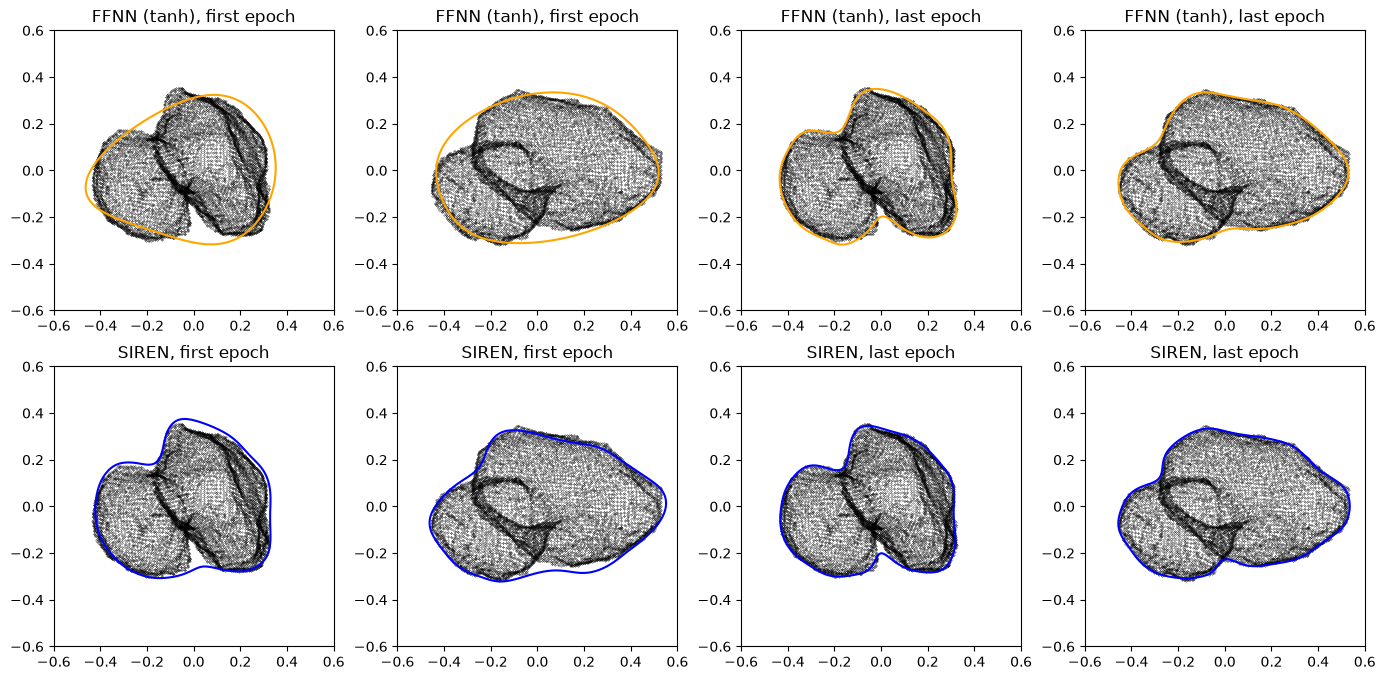

In [10]:
first_epoch = {name: trained(f"{name}_first_epoch", epochs=1, **ARCHITECTURES[name])[0] for name in ["siren", "ffnn_tanh"]}

body = en.load_body("67P")
views = [en.sph2cart(az=30., el=100.), en.sph2cart(az=120., el=75.)]

fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for row, name in enumerate(["ffnn_tanh", "siren"]):
    for column, (stage, model) in enumerate([("first epoch", first_epoch[name]), ("last epoch", models[name])]):
        for i, view in enumerate(views):
            ax = axes[row, 2 * column + i]
            projected = en.project_to_2d(body.mesh_points, view)
            ax.plot(projected[:, 0], projected[:, 1], '.', color='black', markersize=0.5)
            en.plot_silhouette(model, view, ax=ax, extent=0.6, colors=COLORS[name])
            ax.set_title(f"{LABELS[name]}, {stage}")